<a href="https://colab.research.google.com/github/mariajose-vn/MIAR2026/blob/main/Practicas_AO/Algoritmos_AG3_resuelta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos - Actividad Guiada 3

Nombre: Maria Jose Vargas Navarro<br>
URL: https://colab.research.google.com/drive/10WFfowBXyttRa3dblZOAKCDwUIqNa8pu?usp=sharing

GitHub: https://github.com/mariajose-vn/MIAR2026/tree/c81638526558ddef306bdeeeb39e88d34f3bbdde/Practicas_AO

### Carga de librerias

In [ ]:
!pip install requests    #Hacer llamadas http a paginas de la red
!pip install tsplib95    #Modulo para las instancias del problema del TSP

### Carga de los datos del problema

In [ ]:
import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#http://elib.zib.de/pub/mp-testdata/tsp/tsplib/
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
# urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz", file + '.gz')
# !gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#URL alternativa
# file = "swiss42.tsp" ;
# urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)




In [ ]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [ ]:
Aristas

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),


In [ ]:
#Comprobar el nombre del problema
print(problem.name)

#Comprobar el número de Nodos
print(len(Nodos))

#Comprobar los 10 primeros Nodos
print(Nodos[:10])

#Comprobar las 10 primeras Aristas
print(Aristas[:10])

swiss42
42
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9)]



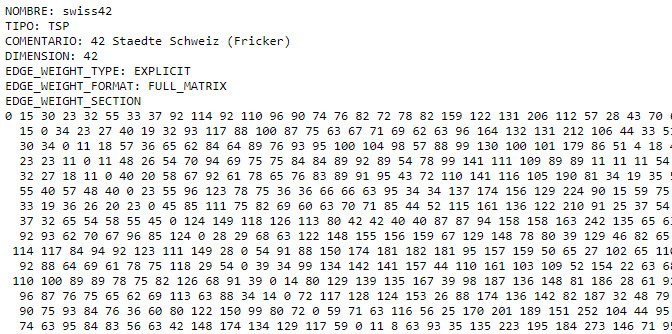

In [ ]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(0, 1)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

15

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo solucion TSP")
    plt.show()

### Funcionas basicas


In [ ]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)

distancia_total(sol_temporal, problem), sol_temporal

(4562,
 [0,
  8,
  10,
  13,
  24,
  38,
  17,
  22,
  3,
  6,
  32,
  7,
  36,
  35,
  21,
  2,
  12,
  20,
  28,
  29,
  39,
  41,
  33,
  30,
  37,
  31,
  27,
  23,
  4,
  11,
  18,
  16,
  14,
  26,
  5,
  19,
  9,
  15,
  40,
  1,
  34,
  25])

## BUSQUEDA ALEATORIA

Mejor solución: [0, 28, 9, 21, 35, 36, 13, 30, 40, 24, 5, 27, 22, 34, 31, 33, 32, 6, 11, 8, 25, 1, 3, 4, 23, 38, 2, 26, 19, 16, 14, 17, 20, 7, 18, 39, 41, 29, 10, 12, 15, 37]
Distancia     : 3513


/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


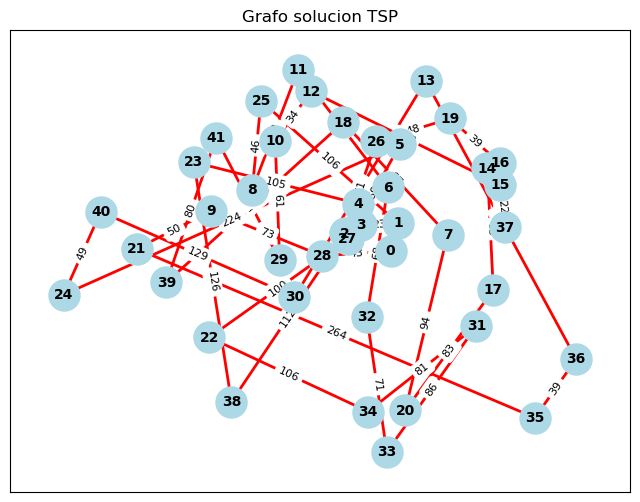

In [ ]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 10000 iteraciones
solucion = busqueda_aleatoria(problem, 10000)

plot_tsp_solution(problem.edge_weights, solucion)

## BUSQUEDA LOCAL

In [ ]:
###############################################################################
# BUSQUEDA LOCAL
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3513
Distancia Mejor Solucion Local: 3287


En la iteracion  38 , la mejor solución encontrada es: [0, 2, 8, 9, 21, 39, 22, 38, 33, 20, 34, 30, 29, 28, 4, 15, 16, 14, 19, 13, 18, 10, 23, 24, 40, 41, 25, 11, 12, 37, 36, 35, 32, 27, 3, 31, 17, 7, 5, 26, 6, 1]
Distancia     : 1917


/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


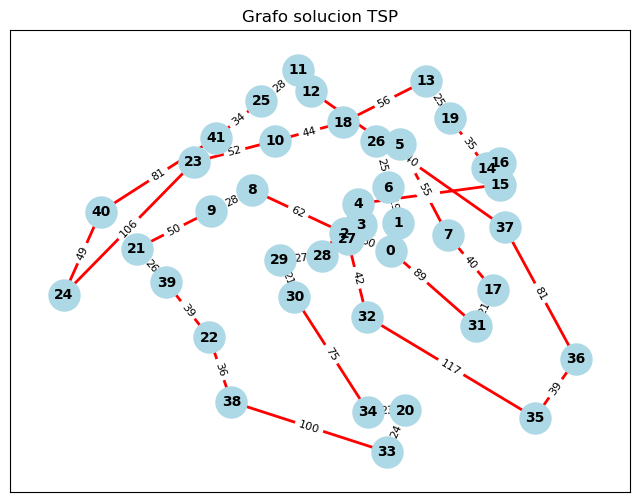

In [ ]:
#Busqueda Local:
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  solucion_referencia = crear_solucion(Nodos)
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(problem)

plot_tsp_solution(problem.edge_weights, sol)

## SIMULATED ANNEALING


In [ ]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

La mejor solución encontrada es [0, 1, 26, 4, 3, 8, 23, 41, 10, 2, 34, 20, 33, 22, 9, 25, 11, 12, 18, 5, 16, 14, 15, 19, 13, 6, 27, 28, 30, 29, 39, 21, 40, 24, 38, 32, 7, 37, 17, 36, 35, 31]
con una distancia total de 1905


/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


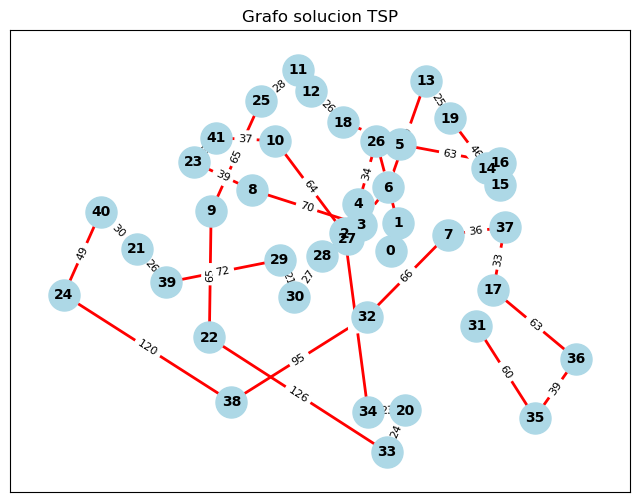

In [ ]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

plot_tsp_solution(problem.edge_weights, sol)

# Actividades extra

**Mejora de algoritmo de búsqueda local**

*   Multiarranque
*   Busqueda en entornos variables

**Recocido simulado**

*   Mejora en la selección de vecinos



## Búsqueda local con Entornos Variables (VNS)

Se agregan dos generadores de vecindad más, aparte de 2-opt: invertir una sub-lista y barajar una sub-lista.

Si el operador actual no mejora, se pasa al siguiente. Si alguno mejora, se vuelve a empezar por el primero. Termina cuando ninguno mejora.

In [ ]:
def invertir_sublista(solucion):
  #Generador de vecindad: invertir el orden de una sub-lista
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1, len(solucion)-1):
    for j in range(i+1, len(solucion)):
      vecina = solucion[:i] + solucion[i:j+1][::-1] + solucion[j+1:]
      distancia_vecina = distancia_total(vecina, problem)
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


def barajar_sublista(solucion, intentos=30):
  #Generador de vecindad: barajar una sub-lista. Probar todas las barajadas posibles no es viable,
  #asi que se prueban varias al azar y se devuelve la mejor
  mejor_solucion = []
  mejor_distancia = 10e100
  for _ in range(intentos):
    i, j = sorted(random.sample(range(1, len(solucion)), 2))
    sublista = solucion[i:j+1]
    random.shuffle(sublista)
    vecina = solucion[:i] + sublista + solucion[j+1:]
    distancia_vecina = distancia_total(vecina, problem)
    if distancia_vecina <= mejor_distancia:
      mejor_distancia = distancia_vecina
      mejor_solucion = vecina
  return mejor_solucion

La mejor solución encontrada es: [0, 1, 6, 7, 17, 31, 35, 36, 37, 15, 16, 14, 19, 13, 5, 26, 18, 12, 11, 25, 41, 23, 9, 40, 24, 21, 39, 22, 38, 30, 29, 8, 10, 4, 3, 27, 2, 28, 32, 34, 33, 20]
Distancia     : 1396


/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


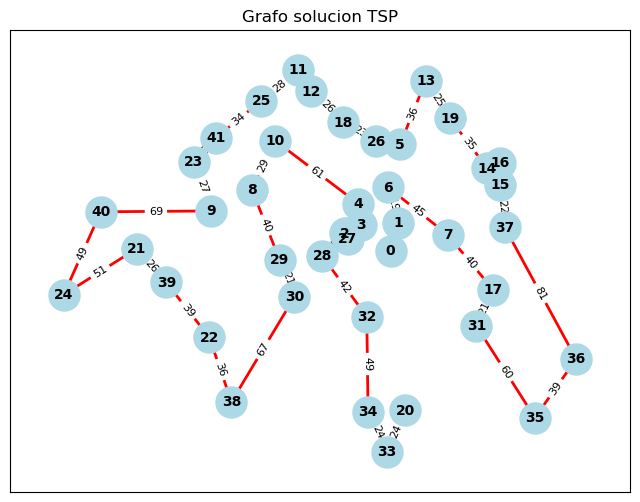

In [ ]:
def busqueda_local_entornos_variables(problem):
  operadores = [genera_vecina, invertir_sublista, barajar_sublista]

  solucion_referencia = crear_solucion(Nodos)
  mejor_distancia = distancia_total(solucion_referencia, problem)

  indice_operador = 0
  while indice_operador < len(operadores):
    vecina = operadores[indice_operador](solucion_referencia)
    distancia_vecina = distancia_total(vecina, problem)

    if distancia_vecina < mejor_distancia:
      solucion_referencia = vecina
      mejor_distancia = distancia_vecina
      indice_operador = 0
    else:
      indice_operador += 1

  print("La mejor solución encontrada es:", solucion_referencia)
  print("Distancia     :", mejor_distancia)
  return solucion_referencia


sol_vns = busqueda_local_entornos_variables(problem)

plot_tsp_solution(problem.edge_weights, sol_vns)

## Recocido simulado con una vecina menos aleatoria

genera_vecina_aleatorio cambia 4 aristas (intercambia 2 nodos al azar). Se prueba invertir un segmento aleatorio en su lugar: cambia solo 2 aristas.

En esta sección, este cambio encuentra una distancia final menor que la versión original.

In [ ]:
def genera_vecina_menos_aleatoria(solucion):
  #Invierte un segmento aleatorio en vez de intercambiar dos nodos sueltos:
  #cambia menos aristas del recorrido (2 en vez de 4)
  i, j = sorted(random.sample(range(1, len(solucion)), 2))
  return solucion[:i] + solucion[i:j+1][::-1] + solucion[j+1:]

La mejor solución encontrada es [0, 3, 4, 2, 27, 32, 28, 30, 29, 9, 8, 10, 11, 25, 41, 23, 40, 21, 24, 39, 38, 22, 34, 33, 20, 31, 35, 36, 17, 1, 7, 37, 15, 14, 16, 19, 13, 6, 5, 26, 18, 12]
con una distancia total de 1598


/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


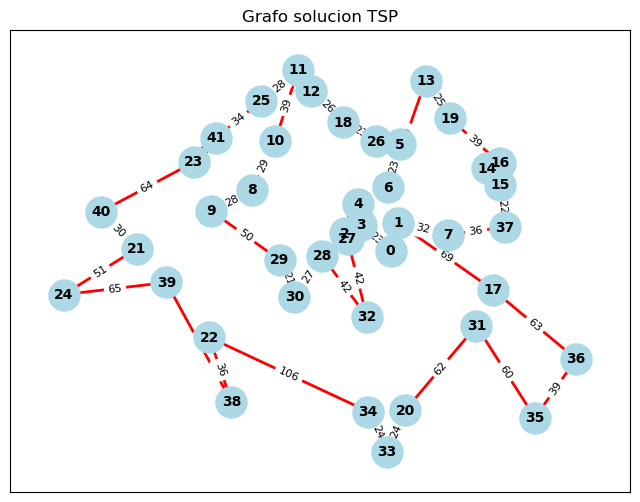

In [ ]:
def recocido_simulado_mejorado(problem, temperatura):
  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []
  mejor_distancia = 10e100

  while temperatura > .0001:
    vecina = genera_vecina_menos_aleatoria(solucion_referencia)
    distancia_vecina = distancia_total(vecina, problem)

    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    if distancia_vecina < distancia_referencia or probabilidad(temperatura, abs(distancia_referencia - distancia_vecina)):
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    temperatura = bajar_temperatura(temperatura)

  print("La mejor solución encontrada es ", end="")
  print(mejor_solucion)
  print("con una distancia total de ", end="")
  print(mejor_distancia)
  return mejor_solucion


sol_sa_mejorado = recocido_simulado_mejorado(problem, 10000000)

plot_tsp_solution(problem.edge_weights, sol_sa_mejorado)